# Pump Scenario Sample Generator & Visualiser

Runs all **10 pump scenarios** (1 normal + 3 failures + 6 decoys) serially using NASA's **progpy CentrifugalPump** model with:
- Cycling voltage load (1h period) for natural signal variation
- Per-signal `process_noise` and `measurement_noise` for realistic sensor jitter
- Wear rates set via `x0` initial state (`wA=0.01` → failure ~6h)

| Group | Failure mode | Discriminating signals | Hard negatives |
|-------|-------------|----------------------|----------------|
| Bearing | `wA=0.01` | shaft speed ↓ **AND** temperature ↑ | setpoint step/ramp (speed ↓, temp flat) |
| Impeller | `wA=0.01` | flow_out ↓ **AND** Qin/Qout ratio > 1 | back-pressure step/ramp (ratio ≈ 1) |
| Seal | `wA=0.01` | flow_out ↓ **AND** flow_in stable (gap grows) | flow-reduction step/ramp (gap ≈ 0) |

In [1]:
import sys, importlib, warnings
warnings.filterwarnings('ignore')

# Make sample_generator importable and reload if already loaded
if "sample_generator" in sys.modules:
    importlib.reload(sys.modules["sample_generator"])
from sample_generator import build_scenarios, run_all

## Run all 9 simulations
Each scenario runs ~360 steps (6 h at 1 sample/min). Faulty scenarios stop early at the failure threshold.

In [2]:
scenarios = build_scenarios()
results = run_all(scenarios)

  Simulating: normal                             

 361 rows  [{'NORMAL': 361}]
  Simulating: pump_bearing_wear                  

 361 rows  [{'NORMAL': 300, 'PRE_FAILURE': 60, 'FAILURE': 1}]
  Simulating: decoy_highload_step                

 361 rows  [{'NORMAL': 361}]
  Simulating: decoy_highload_ramp                

 361 rows  [{'NORMAL': 361}]
  Simulating: pump_impeller_wear                 

...

 361 rows  [{'NORMAL': 361}]
  Simulating: decoy_back_pressure_ramp           

 361 rows  [{'NORMAL': 361}]
  Simulating: pump_radial_wear                   

 361 rows  [{'NORMAL': 300, 'PRE_FAILURE': 60, 'FAILURE': 1}]
  Simulating: decoy_radial_highload_step         

 361 rows  [{'NORMAL': 361}]
  Simulating: decoy_radial_highload_ramp         

 361 rows  [{'NORMAL': 361}]


In [3]:
# Quick summary table
import pandas as pd

rows = []
for name, df in results.items():
    vc = df["label"].value_counts()
    rows.append({
        "scenario": name,
        "rows": len(df),
        "NORMAL": vc.get("NORMAL", 0),
        "PRE_FAILURE": vc.get("PRE_FAILURE", 0),
        "FAILURE": vc.get("FAILURE", 0),
    })
pd.DataFrame(rows).set_index("scenario")

,rows,NORMAL,PRE_FAILURE,FAILURE
scenario,,,,
normal,361,361,0,0
pump_bearing_wear,361,300,60,1
decoy_highload_step,361,361,0,0
decoy_highload_ramp,361,361,0,0
pump_impeller_wear,361,300,60,1
decoy_back_pressure_step,361,361,0,0
decoy_back_pressure_ramp,361,361,0,0
pump_radial_wear,361,300,60,1
decoy_radial_highload_step,361,361,0,0


In [4]:
%matplotlib inline
import matplotlib
matplotlib.rcParams["figure.dpi"] = 150

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sample_generator import (
    COLOURS, LABEL_ALPHA, LABEL_COLOUR,
    _shade_labels, _plot_line, _finish_ax,
)

## Plot 0 — Healthy baseline
All signals stable, every row labelled NORMAL. This is what "nothing is wrong" looks like.

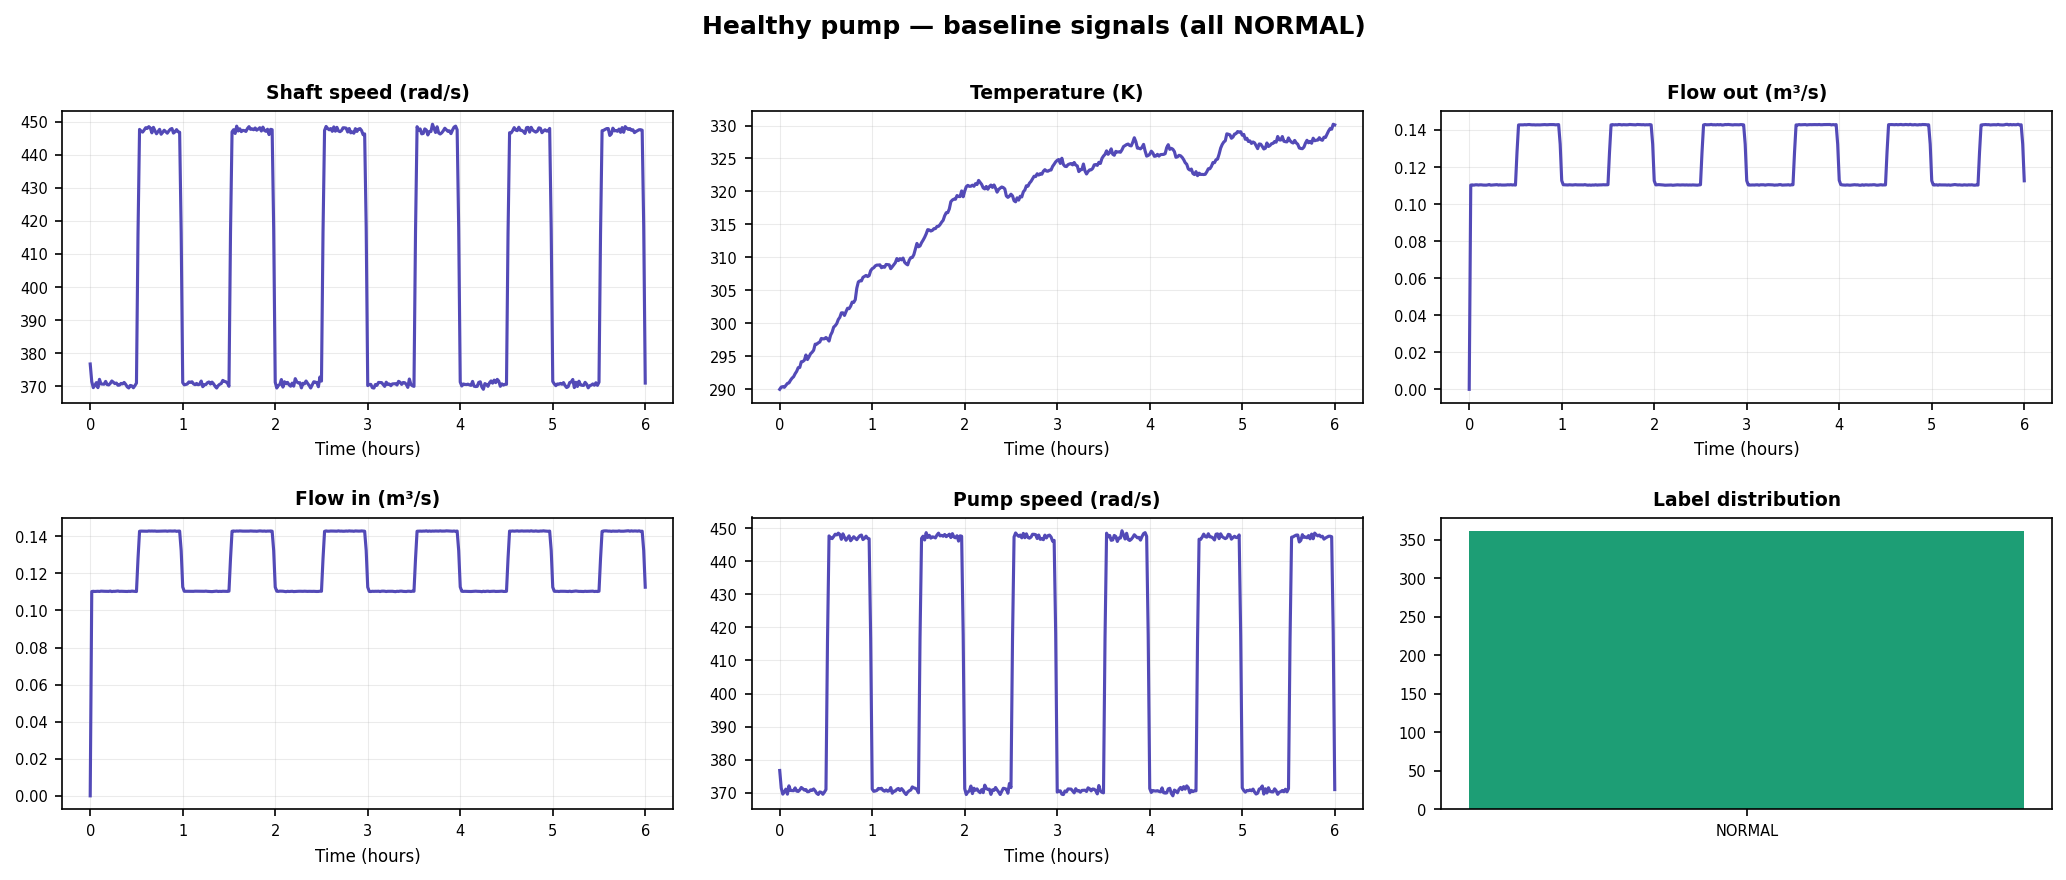

In [5]:
df = results["normal"]

fig, axes = plt.subplots(2, 3, figsize=(14, 6))
fig.suptitle("Healthy pump — baseline signals (all NORMAL)",
             fontsize=12, fontweight="bold")

pairs = [
    ("shaft_speed_rads", "Shaft speed (rad/s)"),
    ("fluid_temp_K",     "Temperature (K)"),
    ("flow_out_m3s",     "Flow out (m\u00b3/s)"),
    ("flow_in_m3s",      "Flow in (m\u00b3/s)"),
    ("pump_speed_rads",  "Pump speed (rad/s)"),
]

for idx, (col, label) in enumerate(pairs):
    ax = axes[idx // 3][idx % 3]
    if col in df.columns:
        ax.plot(df["time_h"], df[col], color=COLOURS["normal"], linewidth=1.5)
    ax.set_title(label, fontsize=9, fontweight="bold")
    ax.set_xlabel("Time (hours)", fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.25, linewidth=0.5)

# Last axis: label distribution bar
ax = axes[1][2]
counts = df["label"].value_counts()
ax.bar(counts.index, counts.values, color=["#1D9E75"])
ax.set_title("Label distribution", fontsize=9, fontweight="bold")
ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()

## Plot 1 — Thrust bearing wear vs high-load decoys

**Both** show Tt rising — but the failure rises **faster** than the operating conditions explain.

- **Failure:** Tt climbs with no speed increase — excess heat from friction (`rThrust * w^2`)
- **Hard negative:** Higher voltage → speed ↑ → Tt rises too, but proportionally — no excess heat

The discrimination problem: you can't just threshold on "Tt is rising" — you need to check whether the rate of rise is explained by the current load.

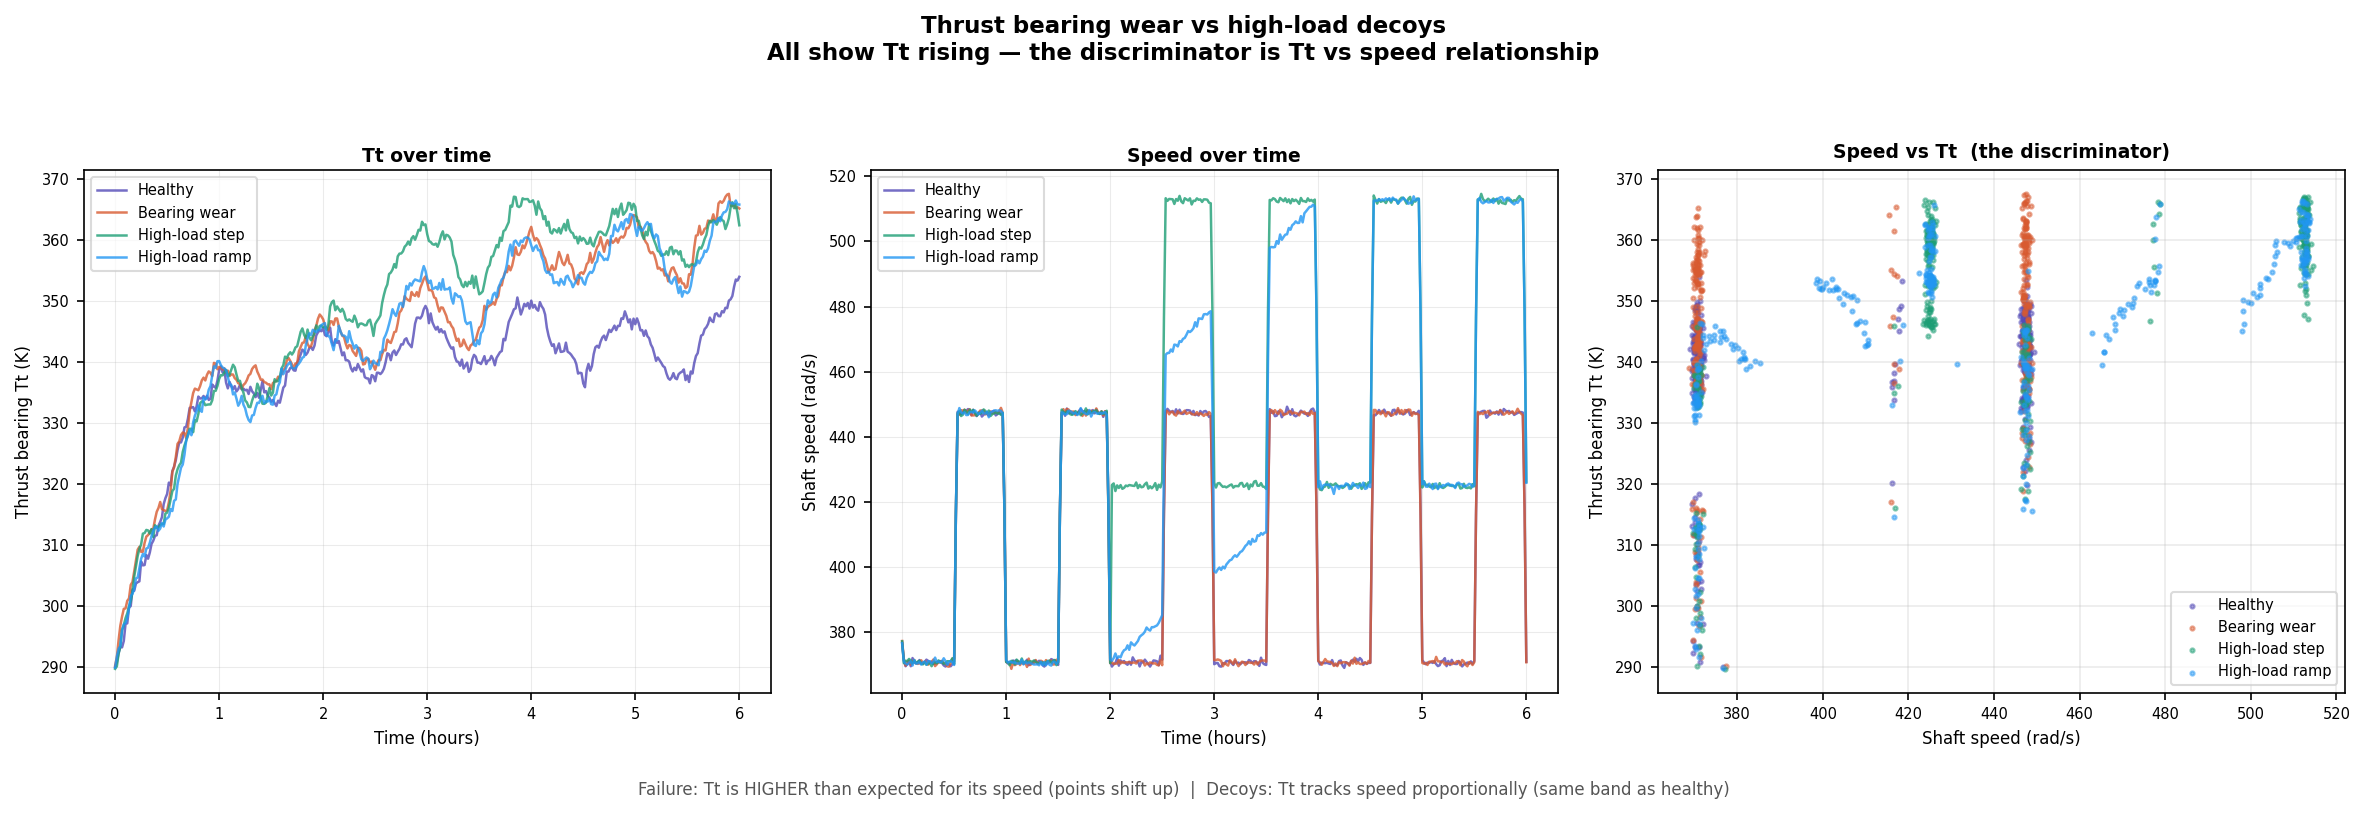

In [6]:
from sample_generator import plot_bearing_group, plot_impeller_group, plot_seal_group

all_bearing = [
    ("normal",              "Healthy",          COLOURS["normal"]),
    ("pump_bearing_wear",   "Bearing wear",     COLOURS["failure"]),
    ("decoy_highload_step", "High-load step",   COLOURS["decoy"]),
    ("decoy_highload_ramp", "High-load ramp",   "#2196F3"),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    "Thrust bearing wear vs high-load decoys\n"
    "All show Tt rising \u2014 the discriminator is Tt vs speed relationship",
    fontsize=11, fontweight="bold", y=1.02
)

ax = axes[0]
for name, label, colour in all_bearing:
    df = results[name]
    ax.plot(df["time_h"], df["thrust_bearing_K"], color=colour, linewidth=1.2, label=label, alpha=0.8)
_finish_ax(ax, "Thrust bearing Tt (K)", "Tt over time")

ax = axes[1]
for name, label, colour in all_bearing:
    df = results[name]
    ax.plot(df["time_h"], df["shaft_speed_rads"], color=colour, linewidth=1.2, label=label, alpha=0.8)
_finish_ax(ax, "Shaft speed (rad/s)", "Speed over time")

ax = axes[2]
for name, label, colour in all_bearing:
    df = results[name]
    ax.scatter(df["shaft_speed_rads"], df["thrust_bearing_K"], color=colour, s=4, alpha=0.5, label=label)
ax.set_xlabel("Shaft speed (rad/s)", fontsize=8)
ax.set_ylabel("Thrust bearing Tt (K)", fontsize=8)
ax.set_title("Speed vs Tt  (the discriminator)", fontsize=9, fontweight="bold")
ax.legend(fontsize=7, framealpha=0.7); ax.grid(True, alpha=0.25); ax.tick_params(labelsize=7)

fig.text(0.5, -0.02,
         "Failure: Tt is HIGHER than expected for its speed (points shift up)  |  "
         "Decoys: Tt tracks speed proportionally (same band as healthy)",
         ha="center", fontsize=8, color="#555")
plt.tight_layout()
plt.show()

## Plot 2 — Impeller wear vs back-pressure decoys (observable signals only)

**Both** show flow dropping — but only the failure shows temperature diverging from the healthy baseline at the same shaft speed.

- **Failure:** flow drops + temp rises → hidden `A` degradation (not directly measurable)
- **Hard negative:** flow drops because back-pressure changed — temp stays near healthy

You can't just watch flow. You need to check: "is the temperature rise explained by the operating conditions, or is there unexplained excess heat?"

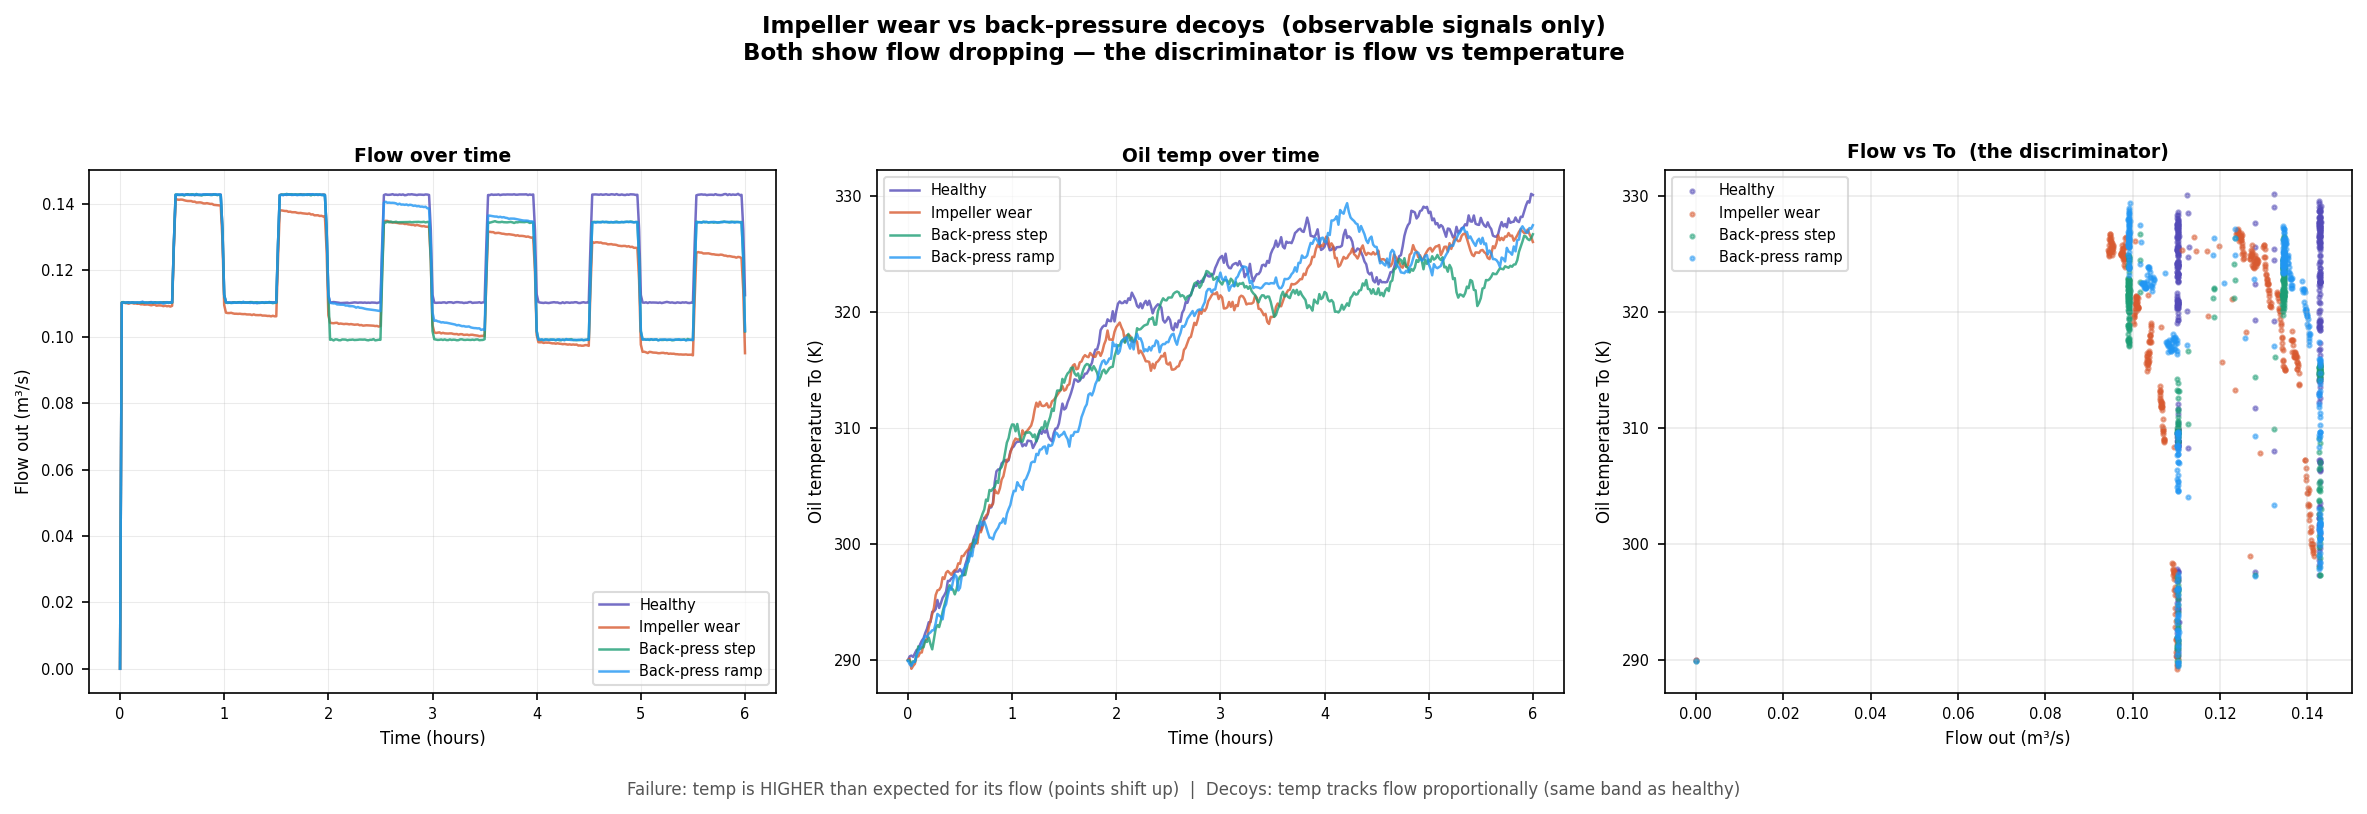

In [7]:
all_impeller = [
    ("normal",                   "Healthy",           COLOURS["normal"]),
    ("pump_impeller_wear",       "Impeller wear",     COLOURS["failure"]),
    ("decoy_back_pressure_step", "Back-press step",   COLOURS["decoy"]),
    ("decoy_back_pressure_ramp", "Back-press ramp",   "#2196F3"),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    "Impeller wear vs back-pressure decoys  (observable signals only)\n"
    "Both show flow dropping \u2014 the discriminator is flow vs temperature",
    fontsize=11, fontweight="bold", y=1.02
)

ax = axes[0]
for name, label, colour in all_impeller:
    df = results[name]
    ax.plot(df["time_h"], df["flow_out_m3s"], color=colour, linewidth=1.2, label=label, alpha=0.8)
_finish_ax(ax, "Flow out (m\u00b3/s)", "Flow over time")

ax = axes[1]
for name, label, colour in all_impeller:
    df = results[name]
    ax.plot(df["time_h"], df["fluid_temp_K"], color=colour, linewidth=1.2, label=label, alpha=0.8)
_finish_ax(ax, "Oil temperature To (K)", "Oil temp over time")

ax = axes[2]
for name, label, colour in all_impeller:
    df = results[name]
    ax.scatter(df["flow_out_m3s"], df["fluid_temp_K"], color=colour, s=4, alpha=0.5, label=label)
ax.set_xlabel("Flow out (m\u00b3/s)", fontsize=8)
ax.set_ylabel("Oil temperature To (K)", fontsize=8)
ax.set_title("Flow vs To  (the discriminator)", fontsize=9, fontweight="bold")
ax.legend(fontsize=7, framealpha=0.7); ax.grid(True, alpha=0.25); ax.tick_params(labelsize=7)

fig.text(0.5, -0.02,
         "Failure: temp is HIGHER than expected for its flow (points shift up)  |  "
         "Decoys: temp tracks flow proportionally (same band as healthy)",
         ha="center", fontsize=8, color="#555")
plt.tight_layout()
plt.show()

## Plot 3 — Radial bearing wear vs high-load decoys

Same logic as thrust bearing: **both** show Tr rising, but the failure has excess heat not explained by load.

- **Failure:** Tr climbs with no speed increase — friction from degraded radial bearing
- **Hard negative:** Higher load → speed ↑ → Tr rises proportionally

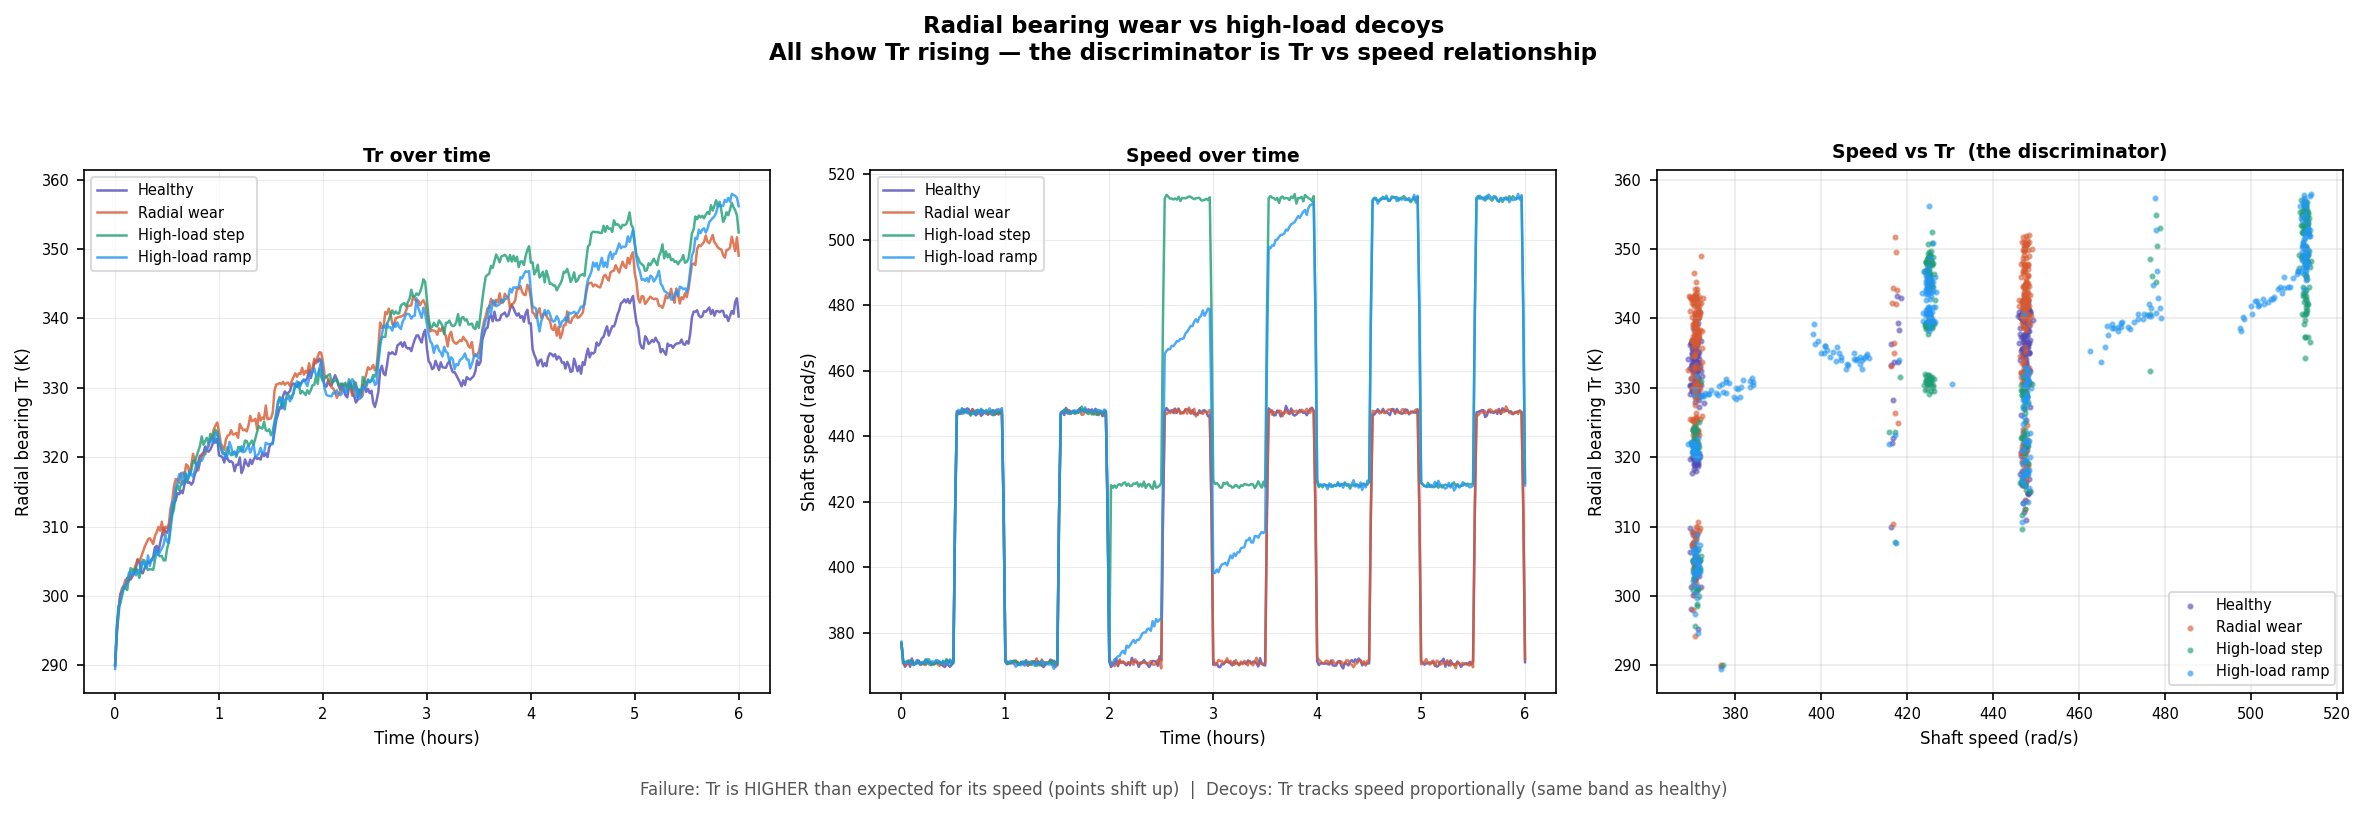

In [8]:
all_radial = [
    ("normal",                       "Healthy",          COLOURS["normal"]),
    ("pump_radial_wear",             "Radial wear",      COLOURS["failure"]),
    ("decoy_radial_highload_step",   "High-load step",   COLOURS["decoy"]),
    ("decoy_radial_highload_ramp",   "High-load ramp",   "#2196F3"),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    "Radial bearing wear vs high-load decoys\n"
    "All show Tr rising \u2014 the discriminator is Tr vs speed relationship",
    fontsize=11, fontweight="bold", y=1.02
)

ax = axes[0]
for name, label, colour in all_radial:
    df = results[name]
    ax.plot(df["time_h"], df["radial_bearing_K"], color=colour, linewidth=1.2, label=label, alpha=0.8)
_finish_ax(ax, "Radial bearing Tr (K)", "Tr over time")

ax = axes[1]
for name, label, colour in all_radial:
    df = results[name]
    ax.plot(df["time_h"], df["shaft_speed_rads"], color=colour, linewidth=1.2, label=label, alpha=0.8)
_finish_ax(ax, "Shaft speed (rad/s)", "Speed over time")

ax = axes[2]
for name, label, colour in all_radial:
    df = results[name]
    ax.scatter(df["shaft_speed_rads"], df["radial_bearing_K"], color=colour, s=4, alpha=0.5, label=label)
ax.set_xlabel("Shaft speed (rad/s)", fontsize=8)
ax.set_ylabel("Radial bearing Tr (K)", fontsize=8)
ax.set_title("Speed vs Tr  (the discriminator)", fontsize=9, fontweight="bold")
ax.legend(fontsize=7, framealpha=0.7); ax.grid(True, alpha=0.25); ax.tick_params(labelsize=7)

fig.text(0.5, -0.02,
         "Failure: Tr is HIGHER than expected for its speed (points shift up)  |  "
         "Decoys: Tr tracks speed proportionally (same band as healthy)",
         ha="center", fontsize=8, color="#555")
plt.tight_layout()
plt.show()